# Project 1: Advanced EDA & Feature Engineering

## Dataset:
IBM HR Analytics Employee Attrition & Performance

## Objective:
The objective of this project is to perform Advanced Exploratory Data Analysis (EDA) and Feature Engineering on the IBM HR Analytics Employee Attrition dataset. This project involves understanding the dataset, identifying and handling missing values, detecting and treating outliers, creating new meaningful features, encoding categorical variables, and preparing a clean dataset suitable for Machine Learning models.

## Tools & Technologies:
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-Learn
- SciPy

## Author:
Madhumitha Gudipally

## Organization:
DecodeLabs Industrial Training Kit – Data Science Project 1

In [26]:
# Import Required Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.impute import SimpleImputer
from sklearn.impute import KNNImputer

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Display all columns
pd.set_option('display.max_columns', None)

print("All libraries imported successfully.")

All libraries imported successfully.


In [2]:
# Load Dataset

df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


In [3]:
# Number of Rows and Columns

print("Dataset Shape:", df.shape)

print("\nNumber of Rows :", df.shape[0])
print("Number of Columns :", df.shape[1])

Dataset Shape: (1470, 35)

Number of Rows : 1470
Number of Columns : 35


In [4]:
# Statistical Summary

df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,2.728571,6502.931293,14313.103401,2.693197,15.209524,3.153741,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,1.102846,4707.956783,7117.786044,2.498009,3.659938,0.360824,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,1.000000,1009.000000,2094.000000,0.000000,11.000000,3.000000,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,2.000000,2911.000000,8047.000000,1.000000,12.000000,3.000000,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,3.000000,4919.000000,14235.500000,2.000000,14.000000,3.000000,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,4.000000,8379.000000,20461.500000,4.000000,18.000000,3.000000,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,4.000000,19999.000000,26999.000000,9.000000,25.000000,4.000000,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [5]:
# Statistical Summary for Categorical Columns

df.describe(include='object')

,Attrition,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,Over18,OverTime
count,1470,1470,1470,1470,1470,1470,1470,1470,1470
unique,2,3,3,6,2,9,3,1,2
top,No,Travel_Rarely,Research & Development,Life Sciences,Male,Sales Executive,Married,Y,No
freq,1233,1043,961,606,882,326,673,1470,1054


In [6]:
# Number of Unique Values in Each Column

df.nunique()

Age                           43
Attrition                      2
BusinessTravel                 3
DailyRate                    886
Department                     3
DistanceFromHome              29
Education                      5
EducationField                 6
EmployeeCount                  1
EmployeeNumber              1470
EnvironmentSatisfaction        4
Gender                         2
HourlyRate                    71
JobInvolvement                 4
JobLevel                       5
JobRole                        9
JobSatisfaction                4
MaritalStatus                  3
MonthlyIncome               1349
MonthlyRate                 1427
NumCompaniesWorked            10
Over18                         1
OverTime                       2
PercentSalaryHike             15
PerformanceRating              2
RelationshipSatisfaction       4
StandardHours                  1
StockOptionLevel               4
TotalWorkingYears             40
TrainingTimesLastYear          7
WorkLifeBa

In [7]:
print("="*50)
print("DATASET OVERVIEW")
print("="*50)

print(f"Rows               : {df.shape[0]}")
print(f"Columns            : {df.shape[1]}")
print(f"Missing Values     : {df.isnull().sum().sum()}")
print(f"Duplicate Records  : {df.duplicated().sum()}")

print("="*50)

DATASET OVERVIEW
Rows               : 1470
Columns            : 35
Missing Values     : 0
Duplicate Records  : 0


# Part 2: Missing Values & Duplicate Handling

Data preprocessing is an important step in Data Science. In this section, we will:

- Check for missing values
- Calculate the percentage of missing values
- Handle missing values (if any)
- Check duplicate records
- Remove duplicate records (if any)
- Verify the cleaned dataset

In [8]:
# Check Missing Values

missing_values = df.isnull().sum()

print("Missing Values in Each Column:\n")
print(missing_values)

Missing Values in Each Column:

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInC

In [9]:
# Total Missing Values

total_missing = df.isnull().sum().sum()

print("Total Missing Values :", total_missing)

Total Missing Values : 0


In [10]:
# Missing Value Percentage

missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": missing_percentage
})

missing_df = missing_df[missing_df["Missing Values"] > 0]

print(missing_df)

Empty DataFrame
Columns: [Missing Values, Percentage]
Index: []


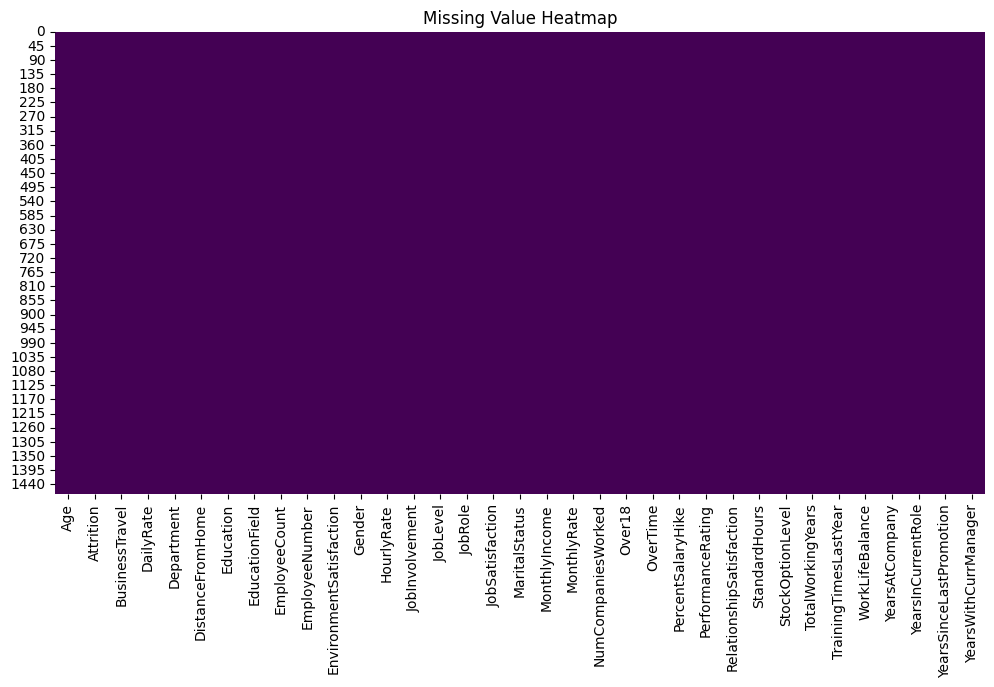

In [11]:
# Missing Value Heatmap

plt.figure(figsize=(12,6))

sns.heatmap(df.isnull(),
            cbar=False,
            cmap='viridis')

plt.title("Missing Value Heatmap")
plt.show()

In [12]:
# Fill Missing Numerical Values using Mean

numeric_columns = df.select_dtypes(include=np.number).columns

df[numeric_columns] = df[numeric_columns].fillna(
    df[numeric_columns].mean()
)

print("Numerical Missing Values Filled Successfully.")

Numerical Missing Values Filled Successfully.


In [13]:
# Fill Missing Numerical Values using Median

numeric_columns = df.select_dtypes(include=np.number).columns

df[numeric_columns] = df[numeric_columns].fillna(
    df[numeric_columns].median()
)

print("Median Imputation Completed.")

Median Imputation Completed.


In [14]:
from sklearn.impute import KNNImputer

numeric_columns = df.select_dtypes(include=np.number).columns

knn = KNNImputer(n_neighbors=5)

df[numeric_columns] = knn.fit_transform(df[numeric_columns])

print("KNN Imputation Completed.")

KNN Imputation Completed.


In [15]:
print("="*50)
print("DATA CLEANING SUMMARY")
print("="*50)

print("Missing Values :", df.isnull().sum().sum())
print("Duplicate Records :", df.duplicated().sum())

print("="*50)

DATA CLEANING SUMMARY
Missing Values : 0
Duplicate Records : 0


# Part 3: Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) helps us understand the dataset by summarizing its main characteristics using statistical methods and visualizations.

In this section, we will:
- Analyze numerical variables
- Analyze categorical variables
- Understand employee attrition patterns
- Visualize distributions and relationships

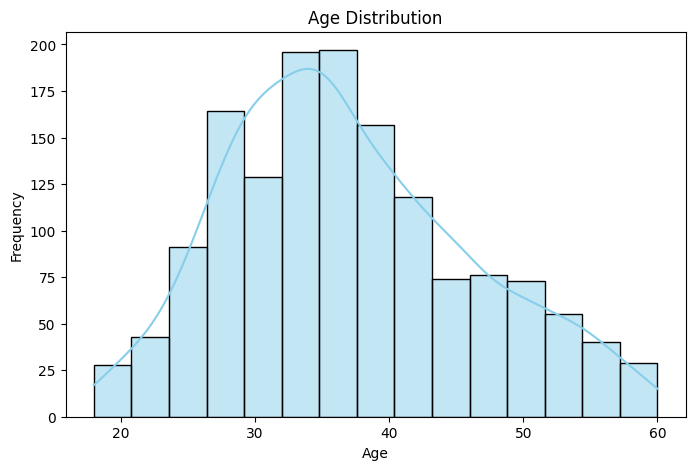

In [16]:
plt.figure(figsize=(8,5))

sns.histplot(df['Age'], bins=15, kde=True, color='skyblue')

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

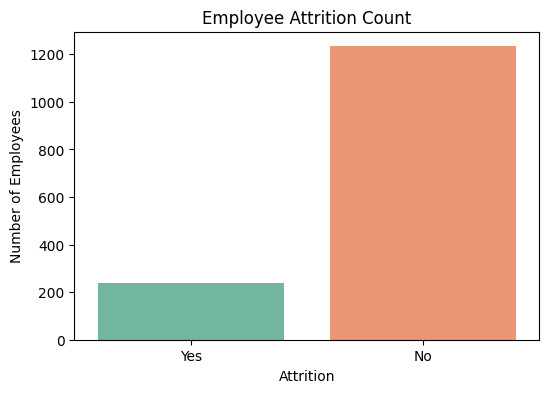

In [17]:
plt.figure(figsize=(6,4))

sns.countplot(x='Attrition', data=df, palette='Set2')

plt.title("Employee Attrition Count")
plt.xlabel("Attrition")
plt.ylabel("Number of Employees")

plt.show()

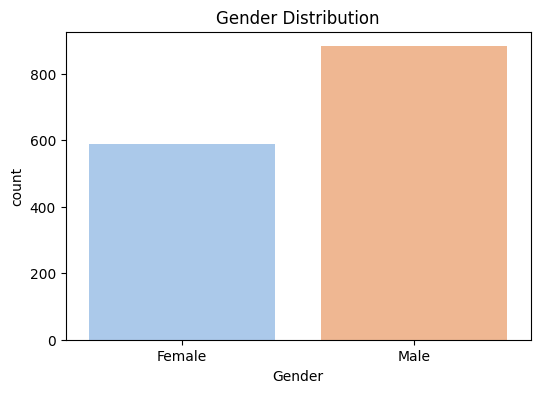

In [18]:
plt.figure(figsize=(6,4))

sns.countplot(x='Gender', data=df, palette='pastel')

plt.title("Gender Distribution")

plt.show()

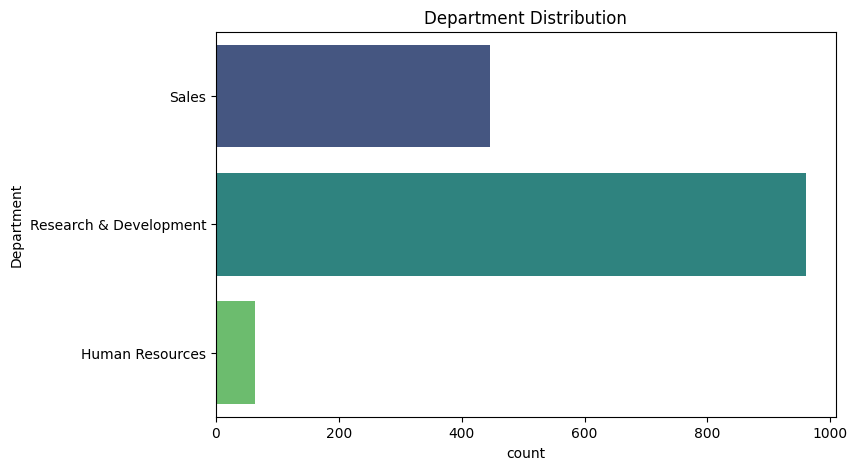

In [19]:
plt.figure(figsize=(8,5))

sns.countplot(y='Department', data=df, palette='viridis')

plt.title("Department Distribution")


plt.show()

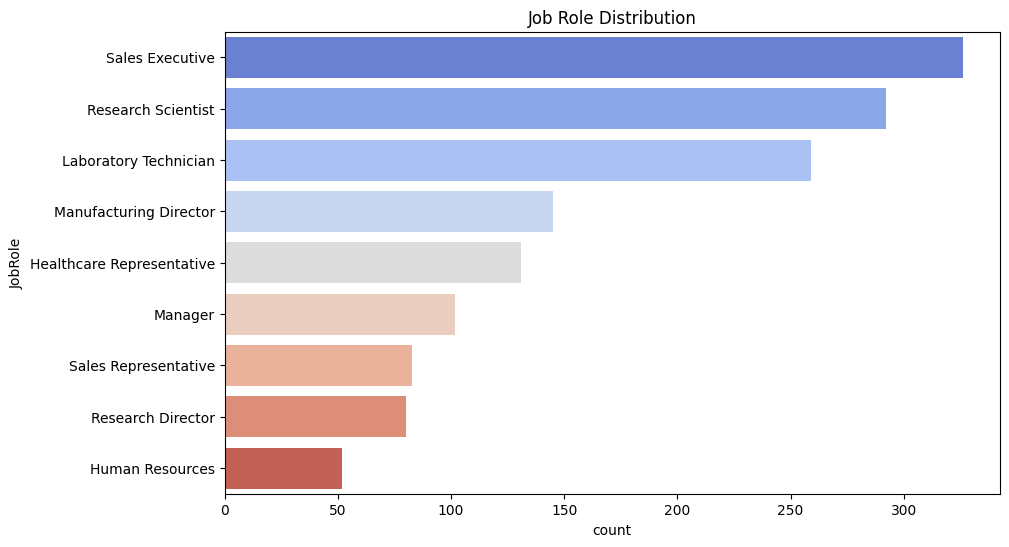

In [20]:
plt.figure(figsize=(10,6))

sns.countplot(y='JobRole', data=df, palette='coolwarm')


plt.title("Job Role Distribution")

plt.show()

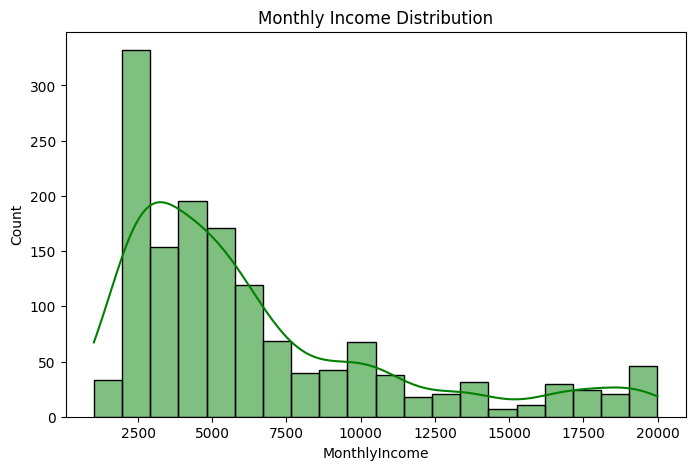

In [21]:
plt.figure(figsize=(8,5))

sns.histplot(df['MonthlyIncome'], bins=20, kde=True, color='green')

plt.title("Monthly Income Distribution")

plt.show()

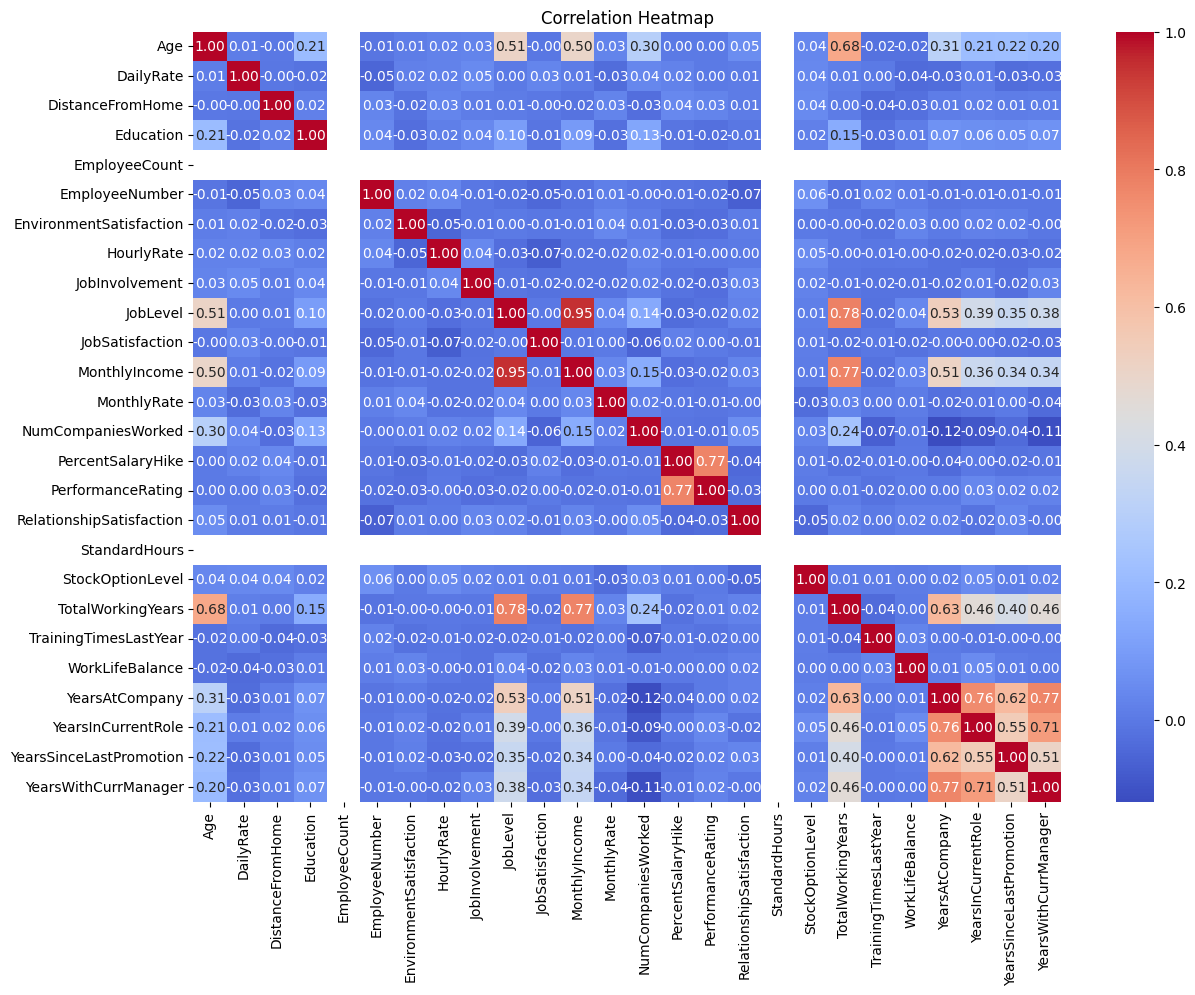

In [22]:
plt.figure(figsize=(14,10))

numeric_df = df.select_dtypes(include='number')

sns.heatmap(numeric_df.corr(),
            annot=True,
            cmap='coolwarm',
            fmt=".2f")

plt.title("Correlation Heatmap")

plt.show()

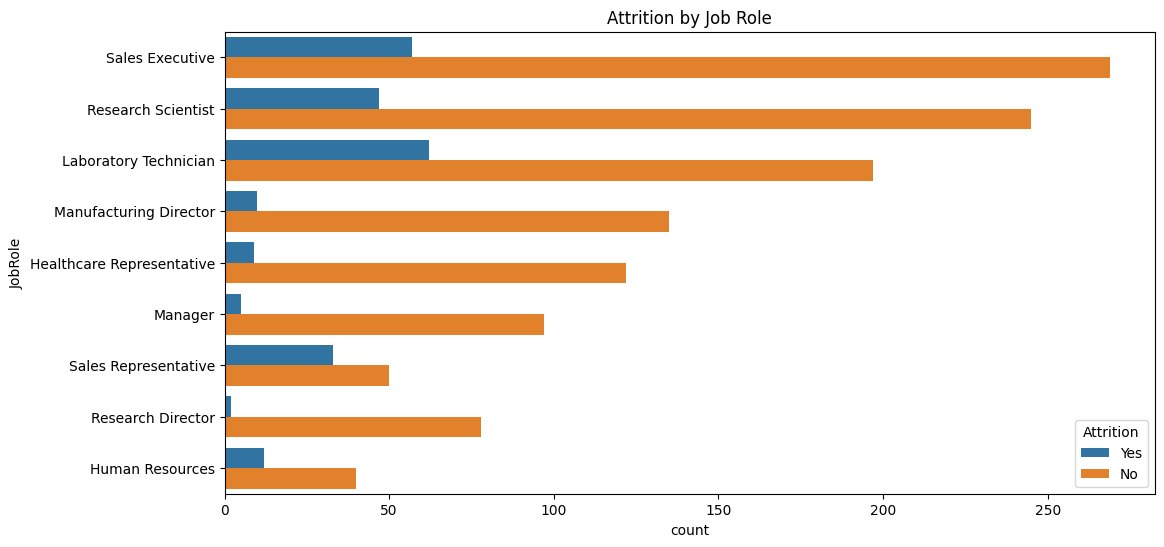

In [23]:
plt.figure(figsize=(12,6))

sns.countplot(y='JobRole', hue='Attrition', data=df)

plt.title("Attrition by Job Role")

plt.show()

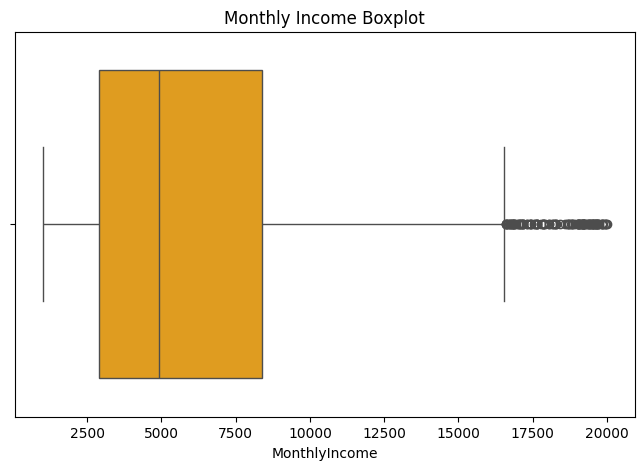

In [24]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df['MonthlyIncome'], color='orange')

plt.title("Monthly Income Boxplot")

plt.show()

In [25]:
print("="*50)
print("EDA COMPLETED")
print("="*50)

print("Total Employees :", len(df))
print("Departments :", df['Department'].nunique())
print("Job Roles :", df['JobRole'].nunique())
print("Male Employees :", (df['Gender']=='Male').sum())
print("Female Employees :", (df['Gender']=='Female').sum())

print("="*50)

EDA COMPLETED
Total Employees : 1470
Departments : 3
Job Roles : 9
Male Employees : 882
Female Employees : 588


# Part 4: Outlier Detection & Treatment

Outliers are extreme values that differ significantly from the rest of the data. They can negatively affect statistical analysis and machine learning models.

In this section, we will:
- Detect outliers using Boxplots
- Detect outliers using the IQR method
- Detect outliers using the Z-Score method
- Handle outliers using Winsorization (Capping)

In [28]:
# Select Numerical Columns

numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns

print("Numerical Columns:")
print(numerical_columns)

Numerical Columns:
Index(['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome',
       'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike',
       'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='str')


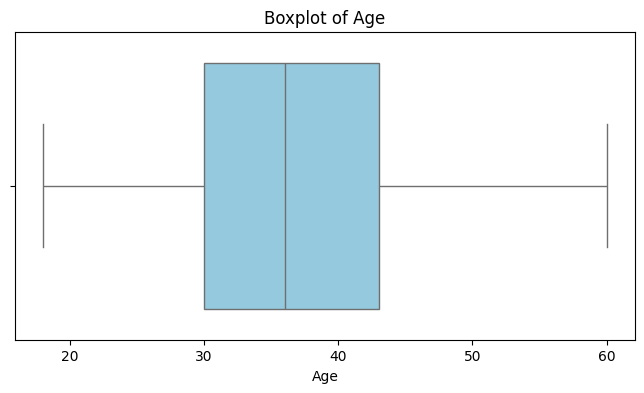

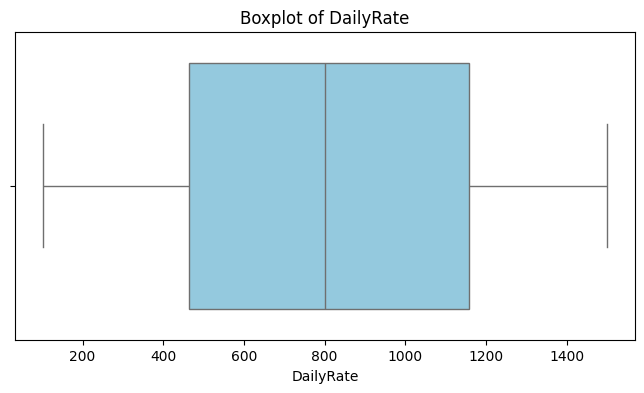

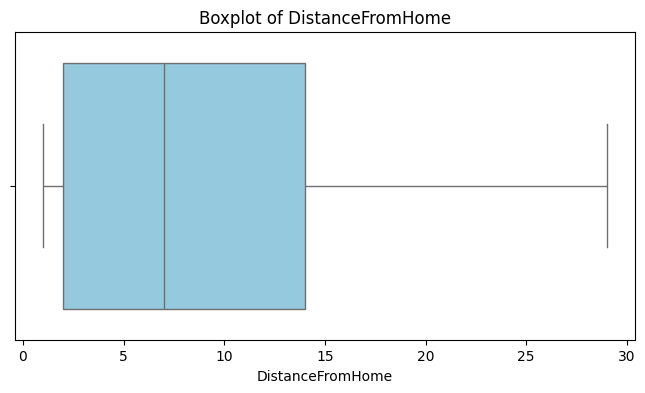

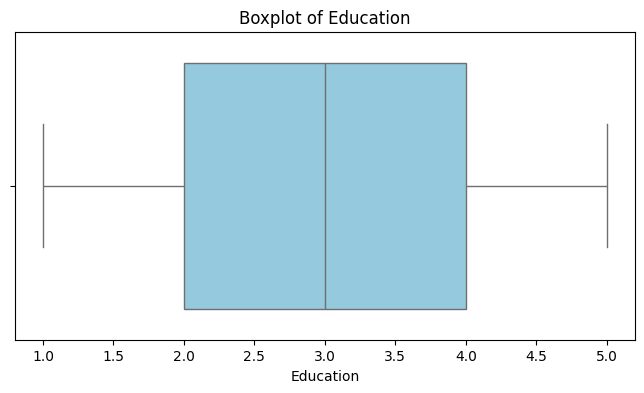

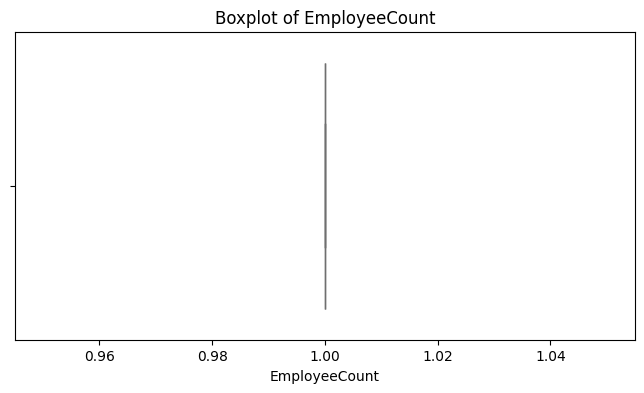

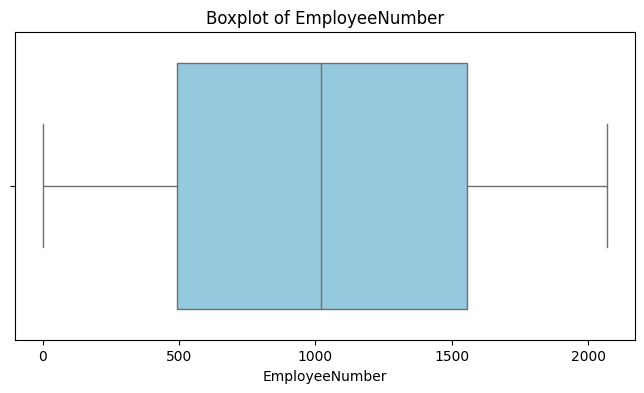

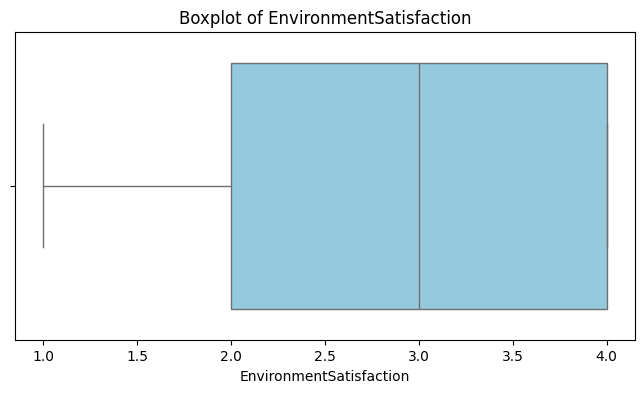

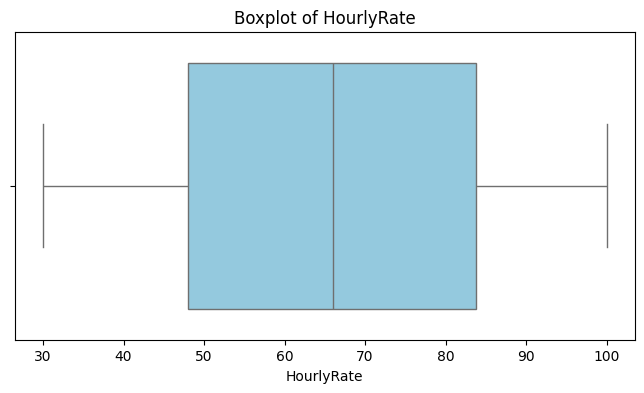

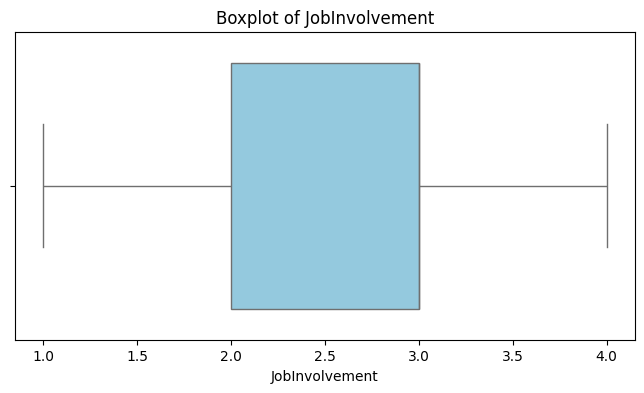

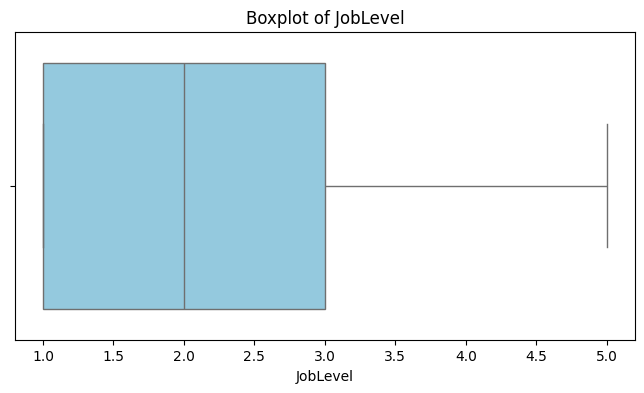

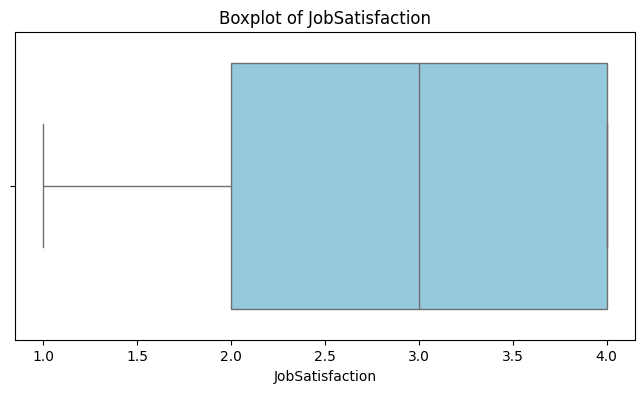

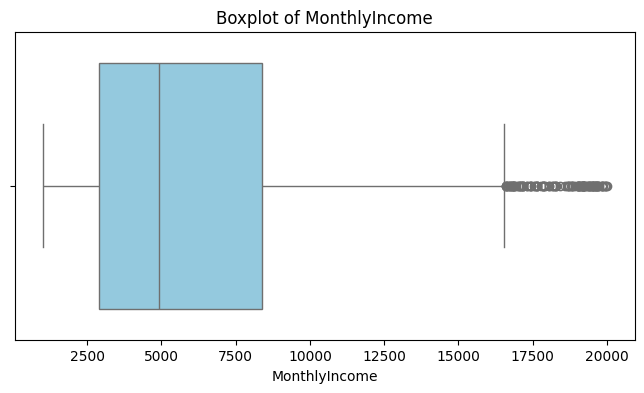

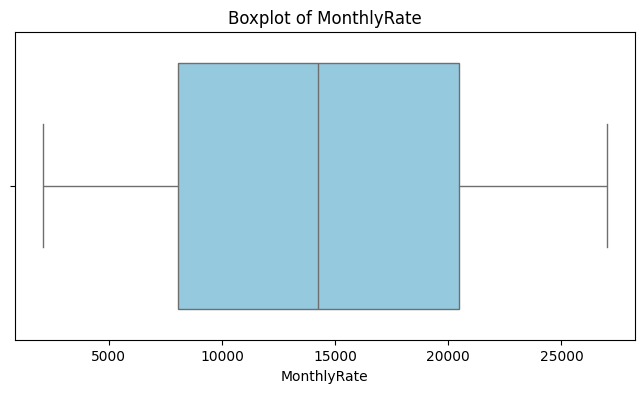

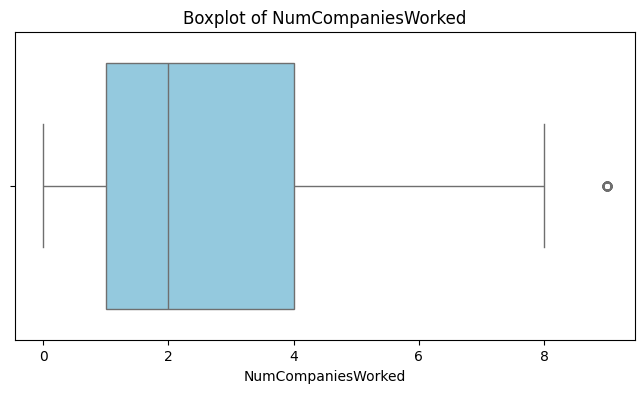

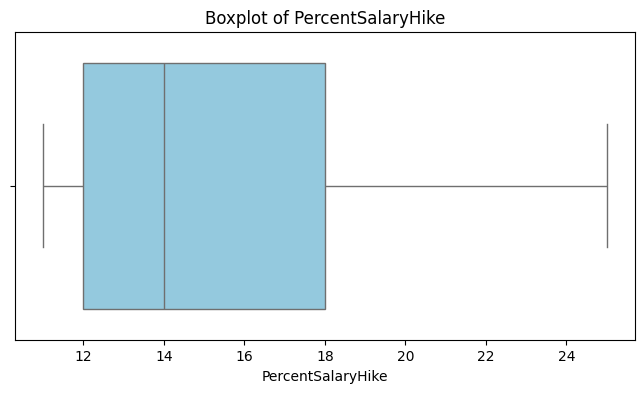

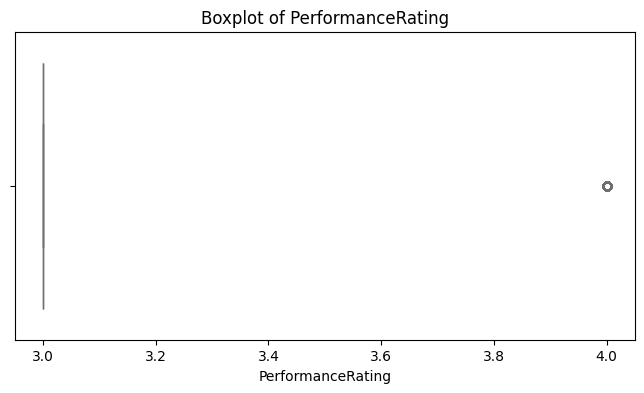

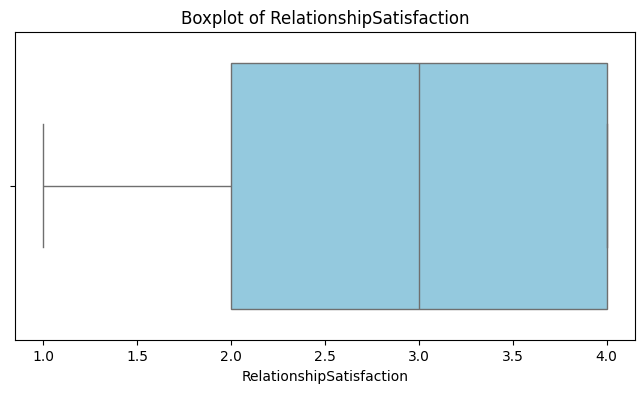

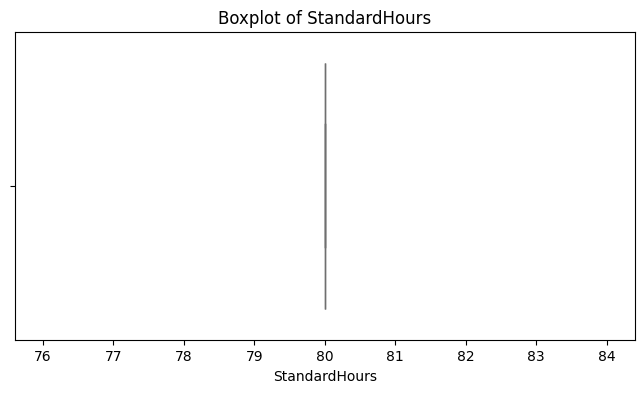

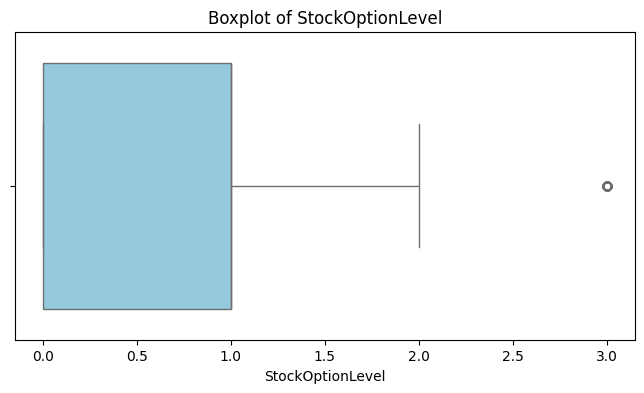

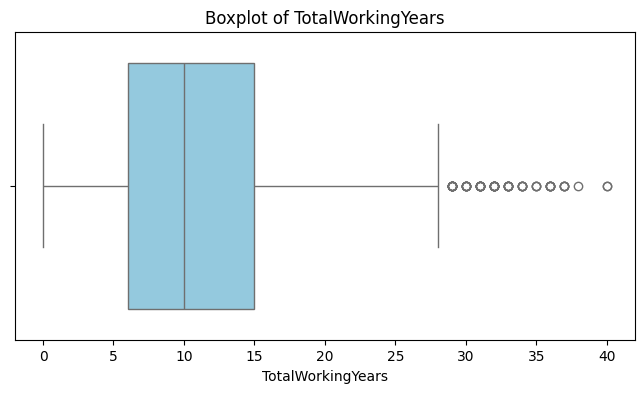

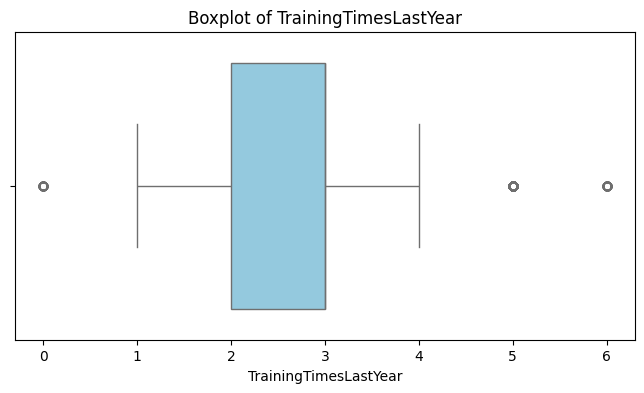

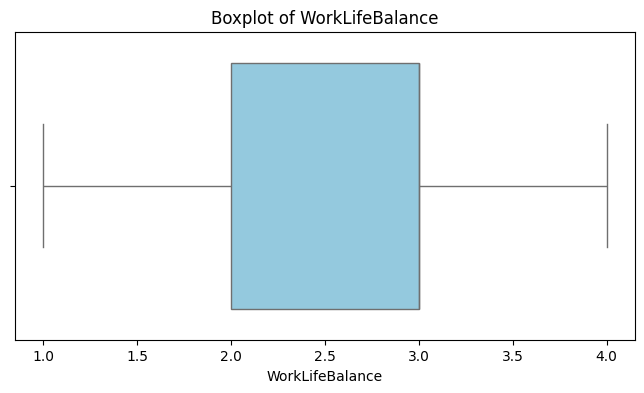

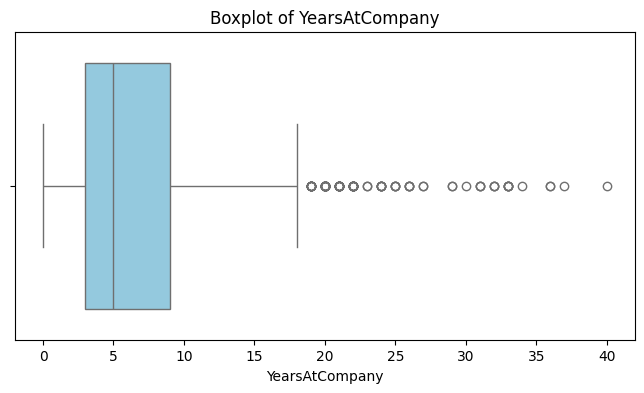

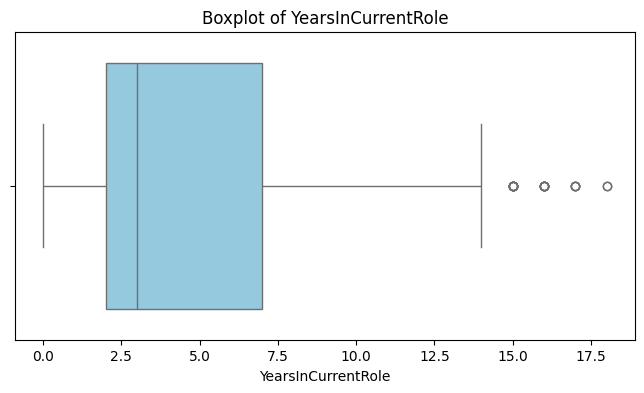

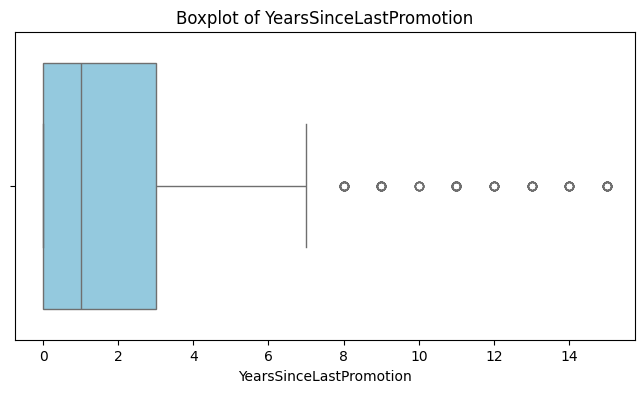

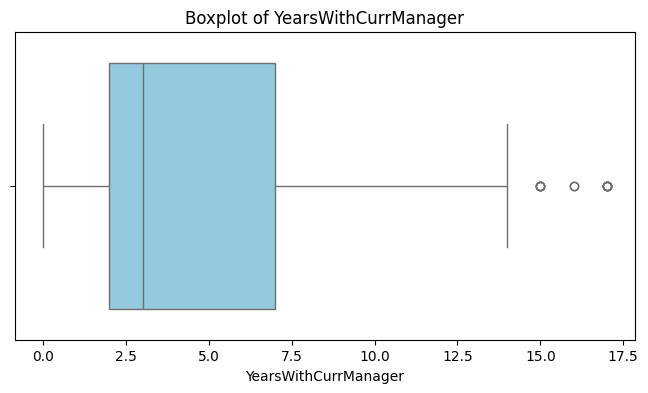

In [29]:
# Boxplots

for column in numerical_columns:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=df[column], color='skyblue')
    plt.title(f'Boxplot of {column}')
    plt.show()

In [31]:
# Detect Outliers using IQR

outlier_summary = {}

for column in numerical_columns:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower) | (df[column] > upper)]

    outlier_summary[column] = len(outliers)

print("Outlier Count using IQR")
print("--------------------------------")

for key, value in outlier_summary.items():
    print(f"{key} : {value}")

Outlier Count using IQR
--------------------------------
Age : 0
DailyRate : 0
DistanceFromHome : 0
Education : 0
EmployeeCount : 0
EmployeeNumber : 0
EnvironmentSatisfaction : 0
HourlyRate : 0
JobInvolvement : 0
JobLevel : 0
JobSatisfaction : 0
MonthlyIncome : 114
MonthlyRate : 0
NumCompaniesWorked : 52
PercentSalaryHike : 0
PerformanceRating : 226
RelationshipSatisfaction : 0
StandardHours : 0
StockOptionLevel : 85
TotalWorkingYears : 63
TrainingTimesLastYear : 238
WorkLifeBalance : 0
YearsAtCompany : 104
YearsInCurrentRole : 21
YearsSinceLastPromotion : 107
YearsWithCurrManager : 14


In [32]:
Q1 = df['MonthlyIncome'].quantile(0.25)
Q3 = df['MonthlyIncome'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

monthly_income_outliers = df[
    (df['MonthlyIncome'] < lower) |
    (df['MonthlyIncome'] > upper)
]

monthly_income_outliers.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
25,53.0,No,Travel_Rarely,1282.0,Research & Development,5.0,3.0,Other,1.0,32.0,3.0,Female,58.0,3.0,5.0,Manager,3.0,Divorced,19094.0,10735.0,4.0,Y,No,11.0,3.0,4.0,80.0,1.0,26.0,3.0,2.0,14.0,13.0,4.0,8.0
29,46.0,No,Travel_Rarely,705.0,Sales,2.0,4.0,Marketing,1.0,38.0,2.0,Female,83.0,3.0,5.0,Manager,1.0,Single,18947.0,22822.0,3.0,Y,No,12.0,3.0,4.0,80.0,0.0,22.0,2.0,2.0,2.0,2.0,2.0,1.0
45,41.0,Yes,Travel_Rarely,1360.0,Research & Development,12.0,3.0,Technical Degree,1.0,58.0,2.0,Female,49.0,3.0,5.0,Research Director,3.0,Married,19545.0,16280.0,1.0,Y,No,12.0,3.0,4.0,80.0,0.0,23.0,0.0,3.0,22.0,15.0,15.0,8.0
62,50.0,No,Travel_Rarely,989.0,Research & Development,7.0,2.0,Medical,1.0,80.0,2.0,Female,43.0,2.0,5.0,Research Director,3.0,Divorced,18740.0,16701.0,5.0,Y,Yes,12.0,3.0,4.0,80.0,1.0,29.0,2.0,2.0,27.0,3.0,13.0,8.0
105,59.0,No,Non-Travel,1420.0,Human Resources,2.0,4.0,Human Resources,1.0,140.0,3.0,Female,32.0,2.0,5.0,Manager,4.0,Married,18844.0,21922.0,9.0,Y,No,21.0,4.0,4.0,80.0,1.0,30.0,3.0,3.0,3.0,2.0,2.0,2.0


In [33]:
from scipy.stats import zscore

z_scores = np.abs(zscore(df[numerical_columns]))

outliers = (z_scores > 3)

print("Total Outliers using Z-Score:")
print(np.sum(outliers))

Total Outliers using Z-Score:
110


In [34]:
# Cap Outliers using IQR

df_capped = df.copy()

for column in numerical_columns:

    Q1 = df_capped[column].quantile(0.25)
    Q3 = df_capped[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df_capped[column] = np.where(
        df_capped[column] < lower,
        lower,
        np.where(
            df_capped[column] > upper,
            upper,
            df_capped[column]
        )
    )

print("Outliers Capped Successfully.")

Outliers Capped Successfully.


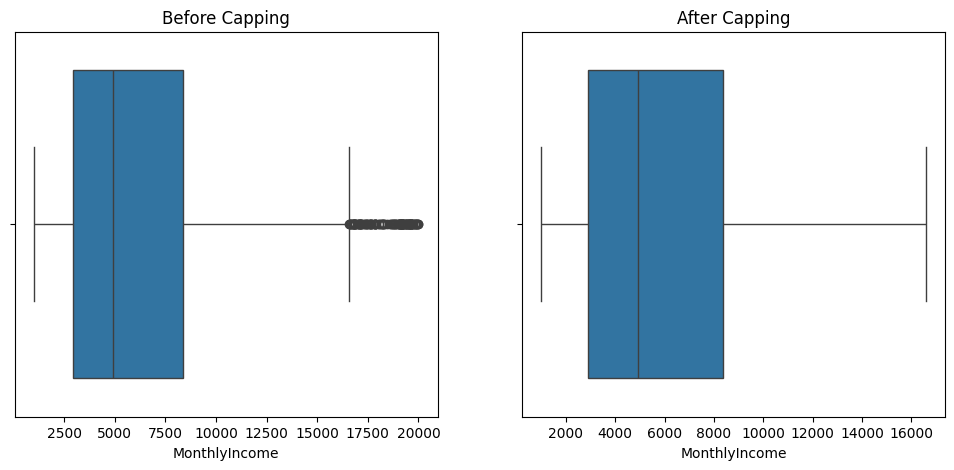

In [35]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.boxplot(x=df['MonthlyIncome'])
plt.title("Before Capping")

plt.subplot(1,2,2)
sns.boxplot(x=df_capped['MonthlyIncome'])
plt.title("After Capping")

plt.show()

In [36]:

outlier_summary_after = {}

for column in numerical_columns:

    Q1 = df_capped[column].quantile(0.25)
    Q3 = df_capped[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df_capped[
        (df_capped[column] < lower) |
        (df_capped[column] > upper)
    ]

    outlier_summary_after[column] = len(outliers)

print("Outliers After Treatment")
print("-----------------------------")

for key, value in outlier_summary_after.items():
    print(f"{key} : {value}")

Outliers After Treatment
-----------------------------
Age : 0
DailyRate : 0
DistanceFromHome : 0
Education : 0
EmployeeCount : 0
EmployeeNumber : 0
EnvironmentSatisfaction : 0
HourlyRate : 0
JobInvolvement : 0
JobLevel : 0
JobSatisfaction : 0
MonthlyIncome : 0
MonthlyRate : 0
NumCompaniesWorked : 0
PercentSalaryHike : 0
PerformanceRating : 0
RelationshipSatisfaction : 0
StandardHours : 0
StockOptionLevel : 0
TotalWorkingYears : 0
TrainingTimesLastYear : 0
WorkLifeBalance : 0
YearsAtCompany : 0
YearsInCurrentRole : 0
YearsSinceLastPromotion : 0
YearsWithCurrManager : 0


In [37]:
# Replace Original Dataset

df = df_capped.copy()

print("Dataset Updated Successfully.")

Dataset Updated Successfully.


In [38]:
print("="*50)
print("OUTLIER TREATMENT COMPLETED")
print("="*50)

print("Method Used : IQR + Winsorization")
print("Dataset Shape :", df.shape)

print("="*50)

OUTLIER TREATMENT COMPLETED
Method Used : IQR + Winsorization
Dataset Shape : (1470, 35)


# Part 5: Feature Engineering

Feature Engineering is the process of creating new features from existing data to improve the performance of machine learning models.

In this section, we create new features that provide additional insights into employee data.